In [1]:
import pandas as pd
df=pd.read_csv("sales_visualization_data.csv")

In [2]:
df

,Date,Product,Region,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
0,2024-04-12,Laptop,East,4,899,37,4.0,3596,4,2
1,2024-12-14,Charger,Central,1,599,46,3.5,599,12,4
2,2024-09-27,Headphones,Central,12,599,62,3.5,7188,9,3
3,2024-04-16,Monitor,South,1,49,63,5.0,49,4,2
4,2024-03-12,Monitor,West,10,299,27,4.0,2990,3,1
...,...,...,...,...,...,...,...,...,...,...
295,2024-06-11,Mouse,South,14,149,19,5.0,2086,6,2
296,2024-07-26,Keyboard,West,8,79,50,4.0,632,7,3
297,2024-06-17,Webcam,East,3,1299,50,3.5,3897,6,2
298,2024-06-09,Webcam,West,2,1299,58,5.0,2598,6,2


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.406667,364.700000,41.296667,4.256667,2794.226667,6.696667,2.560000
std,4.066499,378.086862,13.168143,0.552394,3557.165815,3.310769,1.050434
min,1.000000,19.000000,18.000000,3.500000,19.000000,1.000000,1.000000
25%,4.000000,79.000000,30.000000,4.000000,395.000000,4.000000,2.000000
50%,7.500000,149.000000,42.000000,4.000000,1131.500000,7.000000,3.000000
75%,11.000000,599.000000,52.000000,4.625000,4186.000000,9.000000,3.000000
max,14.000000,1299.000000,64.000000,5.000000,18186.000000,12.000000,4.000000


In [5]:
df.head(10)

,Date,Product,Region,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
0,2024-04-12,Laptop,East,4,899,37,4.0,3596,4,2
1,2024-12-14,Charger,Central,1,599,46,3.5,599,12,4
2,2024-09-27,Headphones,Central,12,599,62,3.5,7188,9,3
3,2024-04-16,Monitor,South,1,49,63,5.0,49,4,2
4,2024-03-12,Monitor,West,10,299,27,4.0,2990,3,1
5,2024-07-07,Keyboard,South,14,599,60,4.0,8386,7,3
6,2024-01-21,Tablet,West,6,49,51,4.5,294,1,1
7,2024-04-12,Laptop,West,5,899,43,4.0,4495,4,2
8,2024-05-01,Laptop,Central,14,1299,58,4.0,18186,5,2
9,2024-08-02,Tablet,North,11,299,20,4.5,3289,8,3


#### Date: Transaction date
#### Product: Product name (Laptop, Phone, Tablet, etc.)
#### Region: Sales region (North, South, East, West, Central)
#### Quantity: Number of units sold
#### UnitPrice: Price per unit
#### CustomerAge: Age of the customer
#### Rating: Product rating (3.5 to 5.0)
#### Revenue: Total revenue (Quantity × UnitPrice)
#### Month: Month number (1-12)
#### Quarter: Quarter number (1-4)

In [6]:
! pip install Matplotlib

#### Basic Line Plot
#### Create a line plot showing the total revenue per month for the year 2024.
#### X-axis: Month
#### Y-axis: Total Revenue
#### Add appropriate labels and title
#### Add a grid for better readability

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

In [8]:
df['Year']

0      2024
1      2024
2      2024
3      2024
4      2024
       ... 
295    2024
296    2024
297    2024
298    2024
299    2024
Name: Year, Length: 300, dtype: int32

In [9]:
monthly_revenue=df.groupby('Month').agg({'Revenue':'sum'}).reset_index()

In [10]:
monthly_revenue

,Month,Revenue
0,1,23623
1,2,93968
2,3,42925
3,4,65537
4,5,103370
5,6,53143
6,7,86507
7,8,95148
8,9,74194
9,10,54171


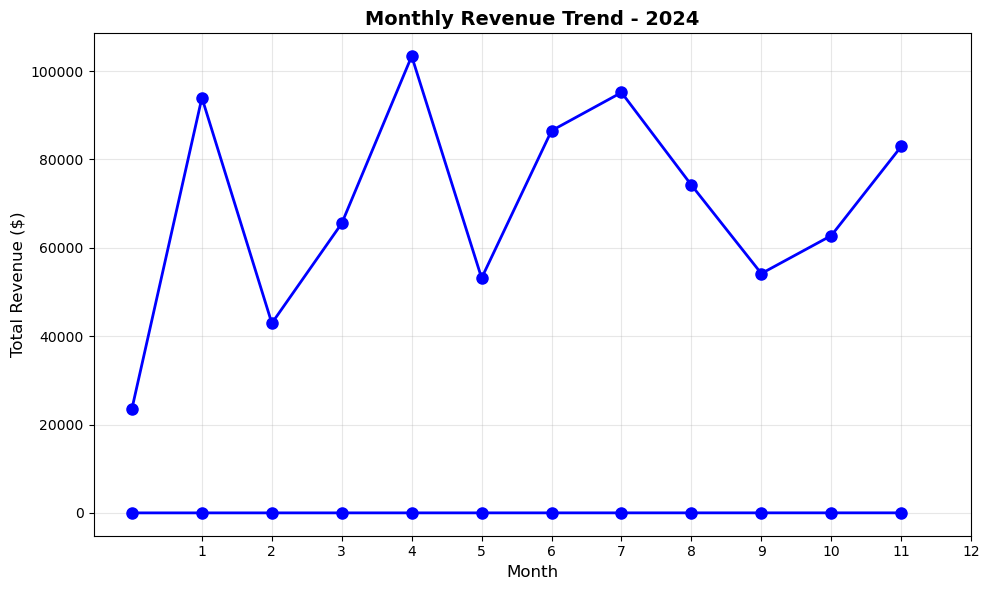

In [11]:
# Create line plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values,marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.title('Monthly Revenue Trend - 2024', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

#### monthly revenue trends for the top 3 products

In [12]:
top3_product=df.groupby('Product')['Revenue'].sum().nlargest(3)

In [14]:
top3_product.reset_index()

,Product,Revenue
0,Laptop,133261
1,Webcam,115034
2,Charger,111666
